In [2]:
import requests

In [6]:
url = 'https://www.gutenberg.org/files/2701/2701-0.txt'

response = requests.get(url)

if response.status_code == 200:
  response.encoding = 'utf-8'
  moby_dick_raw = response.text
  print(len(moby_dick_raw))
  print()
  print(moby_dick_raw[:500])

else:
  print('Status code:', response.status_code)

1219043

*** START OF THE PROJECT GUTENBERG EBOOK 2701 ***




MOBY-DICK;

or, THE WHALE.

By Herman Melville



CONTENTS

ETYMOLOGY.

EXTRACTS (Supplied by a Sub-Sub-Librarian).

CHAPTER 1. Loomings.

CHAPTER 2. The Carpet-Bag.

CHAPTER 3. The Spouter-Inn.

CHAPTER 4. The Counterpane.

CHAPTER 5. Breakfast.

CHAPTER 6. The Street.

CHAPTER 7. The Chapel.

CHAPTER 8. The Pulpit.

CHAPTER 9. The Sermon.

CHAPTER 10. A Bosom Friend.

CHAPTER 11. Nightgown.

CHAPTER 12. Biographical.

CHAPTER 13. Wheelbarro


In [12]:
start_keyword = 'CHAPTER 1. Loomings.'
start_index = moby_dick_raw.find(start_keyword)

end_keyword = '*** END OF THE PROJECT GUTENBERG EBOOK'
end_index = moby_dick_raw.find(end_keyword)

if start_index != -1 and end_index != -1:
  moby_dick_book = moby_dick_raw[start_index:end_index]
  print(len(moby_dick_book))
  print()
  print(moby_dick_book[:100].strip())

else:
  print('Something is worng')
  moby_dick_book = moby_dick_raw

1218824

CHAPTER 1. Loomings.

CHAPTER 2. The Carpet-Bag.

CHAPTER 3. The Spouter-Inn.

CHAPTER 4. The Counte


In [13]:
moby_dick_lowercase = moby_dick_book.lower()

print(moby_dick_lowercase[:150].strip())

chapter 1. loomings.

chapter 2. the carpet-bag.

chapter 3. the spouter-inn.

chapter 4. the counterpane.

chapter 5. breakfast.

chapter 6. the stre


In [17]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.probability import FreqDist
import string
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [18]:
all_tokens = word_tokenize(moby_dick_lowercase)

print(all_tokens[:15])

['chapter', '1.', 'loomings', '.', 'chapter', '2.', 'the', 'carpet-bag', '.', 'chapter', '3.', 'the', 'spouter-inn', '.', 'chapter']


In [19]:
words_no_punc = [word for word in all_tokens if word.isalpha()]

print(len(words_no_punc))
print()
print(words_no_punc[:15])

210259

['chapter', 'loomings', 'chapter', 'the', 'chapter', 'the', 'chapter', 'the', 'counterpane', 'chapter', 'breakfast', 'chapter', 'the', 'street', 'chapter']


In [20]:
english_stopwords = set(stopwords.words('english'))

cleaned_words = [word for word in words_no_punc if word not in english_stopwords]

print(len(cleaned_words))
print()
print(cleaned_words[:15])

103636

['chapter', 'loomings', 'chapter', 'chapter', 'chapter', 'counterpane', 'chapter', 'breakfast', 'chapter', 'street', 'chapter', 'chapel', 'chapter', 'pulpit', 'chapter']


In [21]:
word_frequencies = FreqDist(cleaned_words)

top_25_words = word_frequencies.most_common(25)

for word, count in top_25_words:
  print(f"{word}: {count}")

whale: 1068
one: 899
like: 576
upon: 565
ahab: 494
man: 483
ship: 460
ye: 456
old: 441
would: 429
sea: 375
though: 365
yet: 337
time: 322
captain: 320
long: 311
chapter: 308
still: 308
great: 305
said: 298
boat: 282
must: 282
two: 281
seemed: 281
last: 273


In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

/tmp/ipykernel_3551/789751981.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts, y=words, palette="viridis")


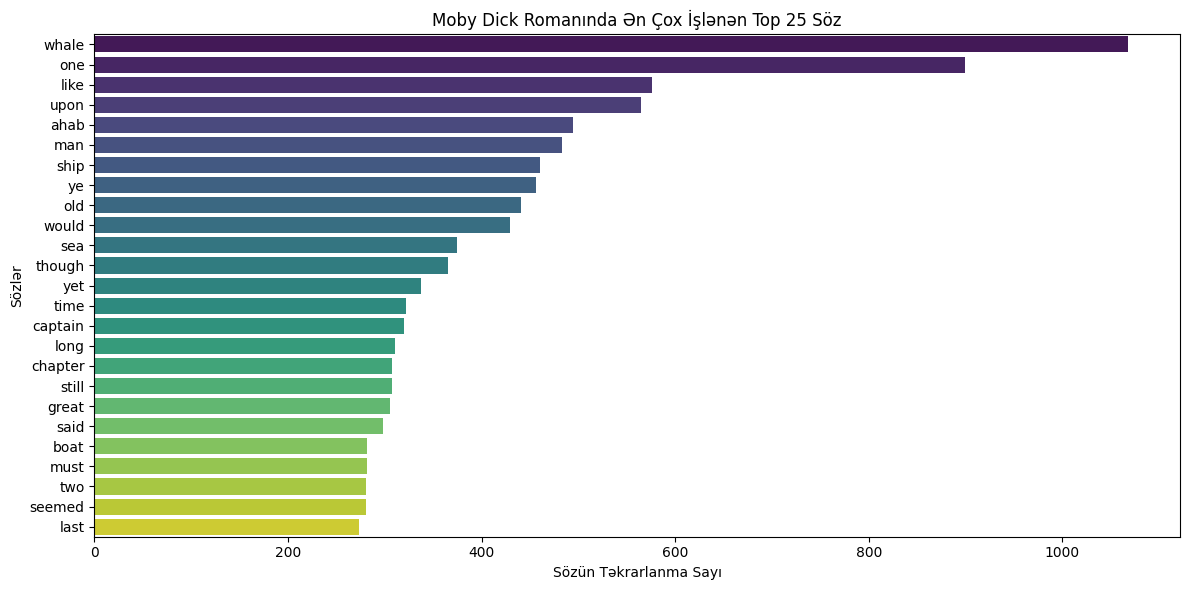

In [23]:
plt.figure(figsize=(12, 6))

words = [item[0] for item in top_25_words]
counts = [item[1] for item in top_25_words]

sns.barplot(x=counts, y=words, palette="viridis")
plt.title("Moby Dick Romanında Ən Çox İşlənən Top 25 Söz")
plt.xlabel("Sözün Təkrarlanma Sayı")
plt.ylabel("Sözlər")
plt.tight_layout()
plt.show()

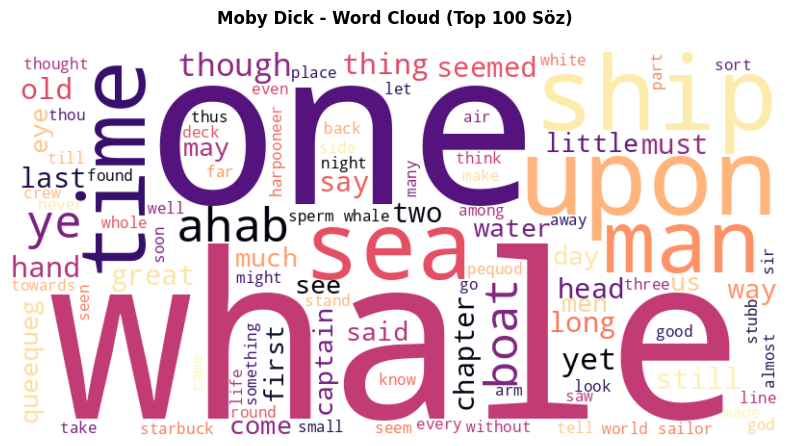

In [28]:
cleaned_text_space = " ".join(cleaned_words)

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white',
    max_words=100,
    colormap='magma'
).generate(cleaned_text_space)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis("off")
plt.title("Moby Dick - Word Cloud (Top 100 Söz)", fontweight='bold', pad=20)
plt.show()